#Pytorch Computer Vision
Art of teaching computer to see

Computer vision is the art of teaching a computer to see.

For example, it could involve building a model to classify whether a photo is of a cat or a dog (binary classification).

Or whether a photo is of a cat, dog or chicken (multi-class classification).

Or figuring out whehter different objects in an image can be seperated(Panoptic segmentation)


In [1]:
# Computer vision libraries:

import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
# This is for transforming augmented images

# Import matplotlib for visualization
import matplotlib.pyplot as plt


print(f"Pytorch Version: {torch.__version__}\ntorchVersion version: {torchvision.__version__}")

Pytorch Version: 2.9.0+cu126
torchVersion version: 0.24.0+cu126


# Getting a dataset

The MNIST fashion Dataset: MNIST stands for Modified National Institute of Standards and Technology.




In [2]:
# Setup the training data
from torchvision import datasets, transforms

train_data = datasets.FashionMNIST(
    root="data", #where to download dataset
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),  # How do we want to transform the data
    target_transform=None  # How do we want to transform labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.74MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 190kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 60000)

In [4]:
# see the first training examples
image, label= train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names  = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx


{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

## Input and output shapes of a computer vision model
We've got a big tensor of values (the image) leading to a single value for the target (the label).

In [7]:
image.shape

torch.Size([1, 28, 28])

Here the image tensor is [1, 28, 28] or more specifically

[color_channels=1, height=28, width=28]
Having color_channels=1 means that the image is grayscale

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [9]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 60000, 60000)

In [10]:
# Check the shape of our images
print("image shape: {image.shape} -> [color_channels, height, width]")
print("Image label: {class_names[labels]}")


image shape: {image.shape} -> [color_channels, height, width]
Image label: {class_names[labels]}


## Visualizing the data

 Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

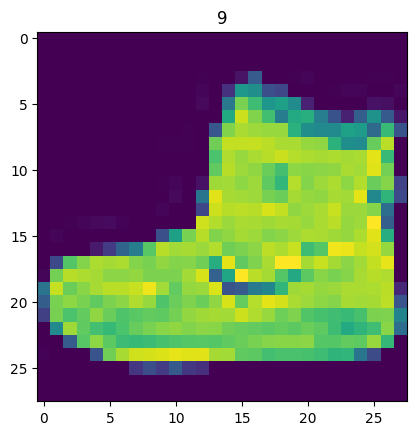

In [11]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f" Image shape: {image.shape}")

plt.imshow(image.squeeze())
plt.title(label)
# image

Text(0.5, 1.0, 'Ankle boot')

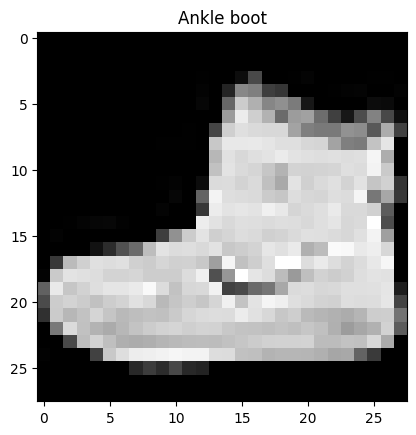

In [12]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])

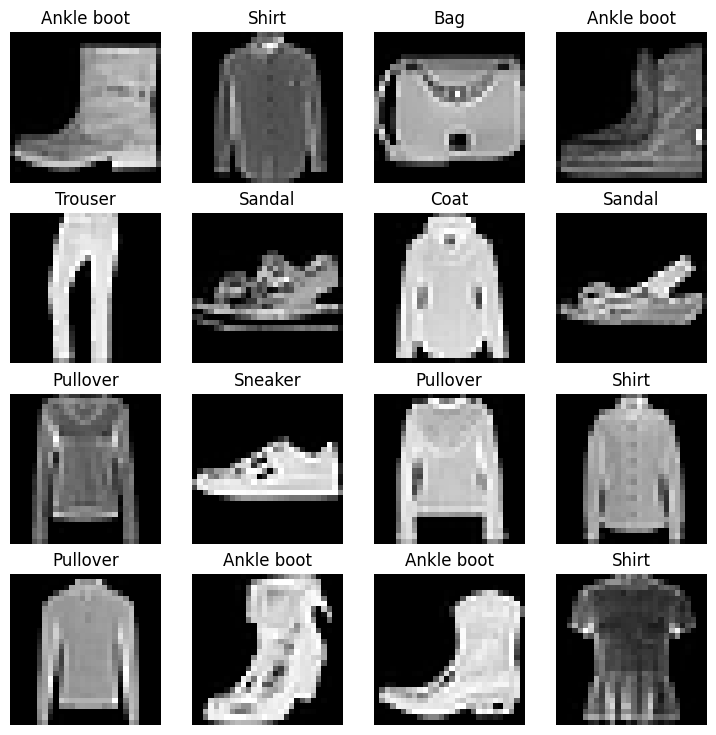

In [13]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

# 2 Prepare DataLoader

Preaparing the torch.utils.data.DataLoader or DataLoader (for short)

The `DataLoader`: does help load the data into a model

For Training and inference

It turns the large `Dataset` into Python iterable of smaller chunks

These smaller chunks are called batches or mini-batches and can be set by the `batch_size` parameter

A good batchsize is 32 for a fair amount of problems

In [14]:

from torch.utils.data import DataLoader

# setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn dataset to iterables (batches)

train_dataloader = DataLoader(dataset=train_data, # dataset to turn into iterable
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              shuffle=True)  # shuffle the data  every epoch?

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)  # we don't have to shuffle the testing data

# Let's check what we made
print(f"DataLoader: {train_dataloader, test_dataloader}")
print(f"Length of train dataLoader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")



DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x7a20f0e5be90>, <torch.utils.data.dataloader.DataLoader object at 0x7a20f0e5b9e0>)
Length of train dataLoader: 1875 batches of 32
Length of test dataloader: 1875 batches of 32


In [15]:
# Check out inside the training dataLoader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

image size: torch.Size([1, 28, 28])
Label: 8, label size: torch.Size([])


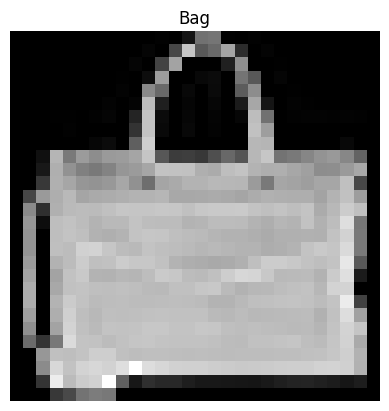

In [16]:
# show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off")
print(f"image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

# Model 0 : Build a baseline model
A simple model is a model to try and improve upon with subsequent models/experiments

We build with nn.Module

This baseline model has two `nn.Linear()` layers

Here we use different layer to start things off

The layer we use is `nn.Flatten()` layer.


In [17]:
# Create a flatten layer
flatten_model = nn.Flatten()
# Flattens a contiguous range of dims into a tensor

# get a single sample
x = train_features_batch[0]


# Flatten the sample
output = flatten_model(x)  # Perform forward pass

print(f" Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f" Shape after flattening: {output.shape} -> [color_channles, height*width]")

# print(x)
# print(output)

 Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
 Shape after flattening: torch.Size([1, 784]) -> [color_channles, height*width]


the `nn.Flatten()` layer took the shape from [color_channels, height, width]  to [color_channels, height*width]

In [18]:
# Here we create tte first model using nn.Flatten() as the first layer

from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):

    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # neural networks like their inputs in vector form
        nn.Linear(in_features=input_shape, out_features=hidden_units), ## in_features = number of features in a data sample (784 pixels)
        nn.Linear(in_features=hidden_units, out_features=output_shape)

    )
  def forward(self, x):
    return self.layer_stack(x)


    input_shape=784 - this is how many features you've got going in the model, in our case, it's one for every pixel in the target image (28 pixels high by 28 pixels wide = 784 features).
    hidden_units=10 - number of units/neurons in the hidden layer(s), this number could be whatever you want but to keep the model small we'll start with 10.
    output_shape=len(class_names) - since we're working with a multi-class classification problem, we need an output neuron per class in our dataset.


In [19]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784,
                               # one for every pixel (28x28)
                               hidden_units = 10,  # how many units in the hidden layer
                              output_shape=len(class_names)
)
model_0.to("cpu")
# Keep the model on CPU to begin with

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

# Setup loss, optimizer and evalutation metrics

In [20]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


In [21]:
# Import accuray metrics
from helper_functions import accuracy_fn

# setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)


# Creating a function for time our experiments

In [22]:
# Creating a function for time our experiments
from timeit import default_timer as timer
def print_train_time(start:float,
                     end:float,
                     device: torch.device=None):
  """
  Print the difference between start and end time.

  Args:
    start (float): Start time of computation (preferred in timeit format).
    end (float): end time of computation.

  Returns:
      float: The time between start and end in seconds (higher is longer)
  """
  total_time = end - start
  print(f" Train time on {device}: {total_time:.3f} sendonds")
  return total_time


In [23]:
start_time = timer()
# some code
end_time = timer()
print_train_time(start=start_time, end=end_time, device="cpu")

 Train time on cpu: 0.000 sendonds


2.8139000008309267e-05

## Creating a training loop and training a model on batches of data

Let's step through it:

1.    Loop through epochs.
2.    Loop through training batches, perform training steps, calculate the train loss per batch.
3.    Loop through testing batches, perform testing steps, calculate the test loss per batch.
4.    Print out what's happening.
5.    Time it all (for fun).



In [24]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set number of epochs
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    train_loss = 0

    # Training loop
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        # Forward pass
        y_pred = model_0(X)

        # Compute loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)

    # Testing loop
    test_loss = 0
    test_acc = 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%")

# Calculate total training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(
    start=train_time_start_on_cpu,
    end=train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device)
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.5904 | Test loss: 0.4743 | Test acc: 83.31%
Epoch: 1
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.4763 | Test loss: 0.4395 | Test acc: 84.63%
Epoch: 2
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.4550 | Test loss: 0.4303 | Test acc: 84.94%
 Train time on cpu: 45.213 sendonds


# Make predictions and get Model 0 results

In [25]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """
  Return a dictionary containng the results of model predicting on data_loader
  Args:
      Model (torch.nn.Module): A PyTorch model that is capable of making predictions on data_loader.
      data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
      loss_fn (torch.nn.Module): The loss function of model.
      accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

  Returns:
  (dict): Results of model making  predction on data_loader.


  """
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      y_pred = model(X)

      # Accumulte the loss an acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,
                        y_pred=y_pred.argmax(dim=1))

    # Scale loss and acc to fing the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)


  return{"Model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}


  #  Calculate the model 0 results on test data
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
                               loss_fn = loss_fn, accuracy_fn=accuracy_fn

)
model_0_results



{'Model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4302612543106079,
 'model_acc': 84.94166666666666}

# Set up devide agnostic code (for the use of GPU if there is one)


In [27]:
torch.cuda.is_available()

True

In [28]:
import torch
device = "cuda" if  torch.cuda.is_available() else "cpu"
device

'cuda'

## Model1 : Building availabel model with non linearity


In [29]:
# Create a model with linear and nonlinear layers
# This is the model of a fully connected (dense) NN, for MNIST
# A feedforward neural net with : One hidden layer and one output layer


class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()

    )
  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)


In [30]:
# Create Instance of model:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device

device(type='cuda', index=0)

# setup loss, optimizer and evaluation metrics

In [31]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

### Creating training and evaluation loops

We call the training loop as `train_step()`
 and testing loop as `test_step()`


In [32]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

    train_loss, train_acc = 0., 0.
    model.to(device)
    model.train()

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # 3. Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Average results
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")



def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):

    test_loss, test_acc = 0., 0.
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)
            test_loss += loss_fn(y_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [33]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 1.42179 | Train accuracy: 54.29%
Test loss: 1.10519 | Test accuracy: 63.05%

Epoch: 1
---------
Train loss: 1.03359 | Train accuracy: 64.61%
Test loss: 0.98026 | Test accuracy: 65.59%

Epoch: 2
---------
Train loss: 0.95996 | Train accuracy: 66.05%
Test loss: 0.94007 | Test accuracy: 66.40%

 Train time on cuda: 45.105 sendonds


Does this work

> this is good

Evaluating our trained `model_1` using `eval_model()` function and see the result


In [34]:
torch.manual_seed(42)

# Note this will error due to eval_mode() not using device agnostic code
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_1_results

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

We need to fix this passing a target `device` parameter to our `eval_model()`


In [35]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
  """Evaluate a given model on a given dataset.

  Args:
      model (torch.nn.Module): A Pytorch model capable of making predictions  on data_loader.
      data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
      loss_fn (torch.nn.Module): The loss function of model.
      accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
      device (str, optional): Target device to compute on. Defaults to device.
  Returns:
      (dict)   : Results of model making predictions on data_loader.

  """
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      # Send data to the target device
      X, y = X.to(device), y.to(device)

      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))

    # Scale loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
           "model_acc": acc
          }

# Calculate the model 1 results with device agnostic code
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
                             loss_fn=loss_fn, accuracy_fn=accuracy_fn,
                             device=device)
model_1_results



{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.9400758743286133,
 'model_acc': 66.39666666666666}

In [36]:
model_0_results

{'Model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4302612543106079,
 'model_acc': 84.94166666666666}

#Convolutional NNs
> * CNNs are known for their ability to learn patterns from visual data
> * Here we dealing with visual data so we can use CNN
>  The CNN model we're going to be using is known as TinyVGG from the CNN Explainer website.

It follow the typical model of a CNN
Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer

In [37]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2


FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

# Stepping through `nn.Conv2d()`

> * nn.Conv2d() also known as convolutional layer
> * nn.MaxPool2d() a.k.a maxPooling layer
  > Question: What does the "2d" in nn.Conv2d() stand for?
  The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.

For other dimensional data (such as 1D for text or 3D for 3D objects) there's also nn.Conv1d() and nn.Conv3d()

## Stepping through `nn.Conv2D()`



    `nn.Conv2d()`, also known as a convolutional layer.
    `nn.MaxPool2d()`, also known as a max pooling layer.



    Question: What does the "2d" in nn.Conv2d() stand for?

>     The 2d is for 2-dimensional data. As in, our images have two dimensions: height and width. Yes, there's color channel dimension but each of the color channel dimensions have two dimensions too: height and width.

>     For other dimensional data (such as 1D for text or 3D for 3D objects) there's also `nn.Conv1d()` and `nn.Conv3d()`.


To test the layer out, we create some toy data jsut like the data used on CNN layer

In [38]:
torch.manual_seed(42)

# Create a bactch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64))   # [batch_size, color_channels, height, width]
test_image = images[0]  # get a single image for testing

print(f"Image batch shape: {image.shape} -> [batch_size, color_channels, height, width]")
print(f"Single Image Shapes: {test_image.shape} -> [color_channles, height, width]")
print(f"Test Image:\n {test_image}")

Image batch shape: torch.Size([1, 28, 28]) -> [batch_size, color_channels, height, width]
Single Image Shapes: torch.Size([3, 64, 64]) -> [color_channles, height, width]
Test Image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
      

eg: of what happens when you change the hyperparameters of an nn.Conv2d() layer

In [39]:
torch.manual_seed(42)

#  Create a convolutional layer with same dimensions as TinyVGG
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here

# Pass the data through the convolutional layer
conv_layer(test_image)

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [40]:
# Adding extra dimension to test image
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [41]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

What if we changed the values of conv_layer?

In [42]:
torch.manual_seed(42)

# Create a new conv_layer with different values (try setting these to whatever value !)
conv_layer_2 = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=(5, 5),
                       stride=2,
                       padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [44]:
# Check out the conv_layer_2 internel parameters
print(conv_layer_2.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [45]:
# Get the shapes of weight and bias tensors within the conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5m kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} => [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5m kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) => [out_channels=10]


## Stepping through `nn.MaxPool2d()`

Let check what happens as we move through `nn.MaxPool2d()`


In [46]:
# Print out original shape without and with unsqueezed dimension
print(f"Test Image Original Shape: {test_image.shape}")
print(f"Text image with unsqueezed dinmensions: {test_image.unsqueeze(dim=0).shape} ")

# Create a sample nn.MaxPool2d Layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f" Shape after going through conv_layer: {test_image_through_conv.shape}")

# Pass the data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through max_pool_layer: {test_image_through_conv_and_max_pool.shape}")

Test Image Original Shape: torch.Size([3, 64, 64])
Text image with unsqueezed dinmensions: torch.Size([1, 3, 64, 64]) 
 Shape after going through conv_layer: torch.Size([1, 10, 62, 62])
Shape after going through max_pool_layer: torch.Size([1, 10, 31, 31])


In [47]:
# Working on a smaller tensor
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 2, 3, 2))
print(f"Random tensor: \n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Creating a maxpool  layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)   # see what happens when you change the kernel_size value

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"Max pool tensor: \n{max_pool_tensor} <- This is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")



Random tensor: 
tensor([[[[ 0.3367,  0.1288],
          [ 0.2345,  0.2303],
          [-1.1229, -0.1863]],

         [[ 2.2082, -0.6380],
          [ 0.4617,  0.2674],
          [ 0.5349,  0.8094]]]])
Random tensor shape: torch.Size([1, 2, 3, 2])
Max pool tensor: 
tensor([[[[0.3367]],

         [[2.2082]]]]) <- This is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 2, 1, 1])


Essentially, every layer in a neural network is trying to compress data from higher dimensional space to lower dimensional space.

In other words , take a lot of numbers and learn patterns in those numbers, patterns that are predictive whilst also being smaller in size than the original values



## Setup Loss function and Optimizer for `model2`

In [48]:
# Set up loss function/eval metrics/optimizer

from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

##Training and testing `model_2` using the training and test functions


In [49]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


# Messure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")
  train_step(data_loader=train_dataloader,
             model=model_2,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device
  )
  test_step(data_loader=test_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device
  )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)






  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 0.59412 | Train accuracy: 78.38%
Test loss: 0.35878 | Test accuracy: 87.16%

Epoch: 1
--------
Train loss: 0.36158 | Train accuracy: 86.97%
Test loss: 0.31729 | Test accuracy: 88.42%

Epoch: 2
--------
Train loss: 0.32340 | Train accuracy: 88.33%
Test loss: 0.28586 | Test accuracy: 89.64%

 Train time on cuda: 54.946 sendonds


In [50]:
# Evaluating model_2's results

model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results



{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.28585588932037354,
 'model_acc': 89.645}

# Compare the rersults and training time

We've trained 3 different models
> 1. `model_0` - the baseline model with two `nn.Linear()` layers
>2. `model_1`  - the same setup as the baseline model except with nn.ReLU() layer is b/w the `nn.Linear()` layers  
>3. `model_2` - our first CNN model that mimics the TinyVGG architecture on the CNN Explainer website.

And this is a regular practice in ML:
Building multiple models and performing multiple training and experiments to see which performs best.


In [51]:
# Combining the model results and find out which is best

import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])

compare_results

,Model_name,model_loss,model_acc,model_name
0,FashionMNISTModelV0,0.430261,84.941667,NaN
1,NaN,0.940076,66.396667,FashionMNISTModelV1
2,NaN,0.285856,89.645000,FashionMNISTModelV2


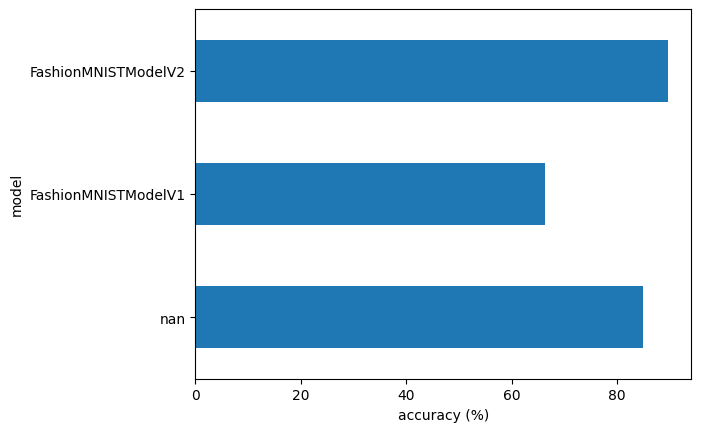

In [52]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

## Make and evaluate random predictions with best model

In [53]:
def make_predictions(model: torch.nn.Module,
                     data:  list,
                     device: torch.device = device):

  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare Sample
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Forward pass (model outputs raw logit)
      pred_logits = model(sample)

      # Get the predictions probability (logit -> Prediction probability)
      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      # Get pred_prob off GPU for better calculations
      pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)





In [54]:
# We can add training time values too
# Addig the training times to results comaprison
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]

compare_results

,Model_name,model_loss,model_acc,model_name,training_time
0,FashionMNISTModelV0,0.430261,84.941667,NaN,45.212927
1,NaN,0.940076,66.396667,FashionMNISTModelV1,45.104976
2,NaN,0.285856,89.645000,FashionMNISTModelV2,54.945651


Text(0, 0.5, 'model')

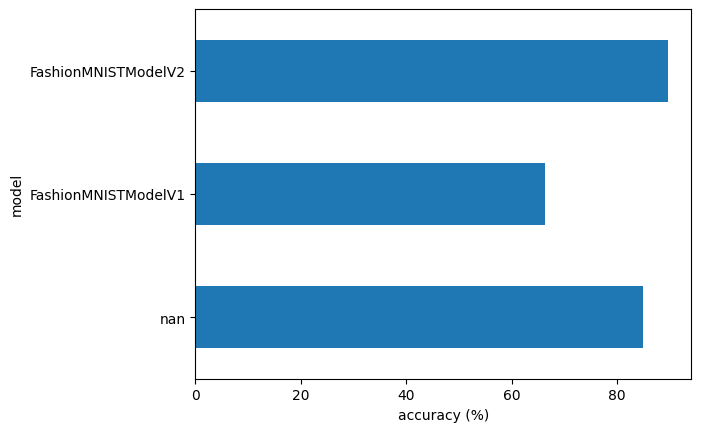

In [55]:
# Visualizing the model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

## Make and evaluate random predictions with best model

We've compared our models to each other, let's further evaluate our best performing model, `model_2`.

To do so, let's create a function `make_predictions()` where we can pass the model and some data for it to predict on.

In [56]:
def make_prediction(model:torch.nn.Module, data: list, device:torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare sample
      sample = torch.unsqueeze(sample, dim=0).to(device)   # Add an extra dimension and send sample to device

      # Forward pass (Model outputs raw logit)
      pred_logit = model(sample)

      # Get the predictions probability (logit -> prediction probability)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      # Get pred_prob off GPU for further calculations
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn the list into a tensor
  return torch.stack(pred_probs)



In [57]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample , label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

# View the first test samples shape and label
print(f" Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")


 Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 6 (Shirt)


In [58]:
# Make predictions on test samples with model 2
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# View fist two prediction probabilities list
pred_probs[:2]

tensor([[5.5764e-01, 2.0897e-03, 2.2308e-03, 3.9169e-01, 3.5243e-04, 5.4430e-06,
         4.5600e-02, 1.3200e-04, 2.4412e-04, 9.1631e-06],
        [1.6291e-05, 9.9986e-01, 6.5978e-07, 3.1624e-05, 9.1972e-05, 1.9803e-07,
         1.2096e-06, 5.0137e-07, 2.3270e-06, 4.0455e-08]])

In [59]:
# Make predictions on test samples with model_2
pred_probs=make_predictions(model=model_2,
                            data=test_samples)
# View first two prediction probabilities list
pred_probs[:2]


tensor([[5.5764e-01, 2.0897e-03, 2.2308e-03, 3.9169e-01, 3.5243e-04, 5.4430e-06,
         4.5600e-02, 1.3200e-04, 2.4412e-04, 9.1631e-06],
        [1.6291e-05, 9.9986e-01, 6.5978e-07, 3.1624e-05, 9.1972e-05, 1.9803e-07,
         1.2096e-06, 5.0137e-07, 2.3270e-06, 4.0455e-08]])

And now we can go from prediction probabilities to prediction labels by taking the `torch.argmax()` of the output of the `torch.softmax()` activation function.

In [60]:
# Turn the predictions probabilities into prediction labels by taking the argmax()
pred_classes = torch.argmax(pred_probs, dim=1)
pred_classes

tensor([0, 1, 9, 0, 0, 0, 0, 2, 8])

In [61]:
# Are our predictions in the same form as the test labels
test_labels, pred_classes

([6, 1, 9, 0, 0, 0, 0, 2, 8], tensor([0, 1, 9, 0, 0, 0, 0, 2, 8]))

this large difference in the result says that we need to change the data a lot to make the `model_2` better!

Since we're dealing with image data, let's stay true to the data explorer's motto.

"Visualize, visualize, visualize!"

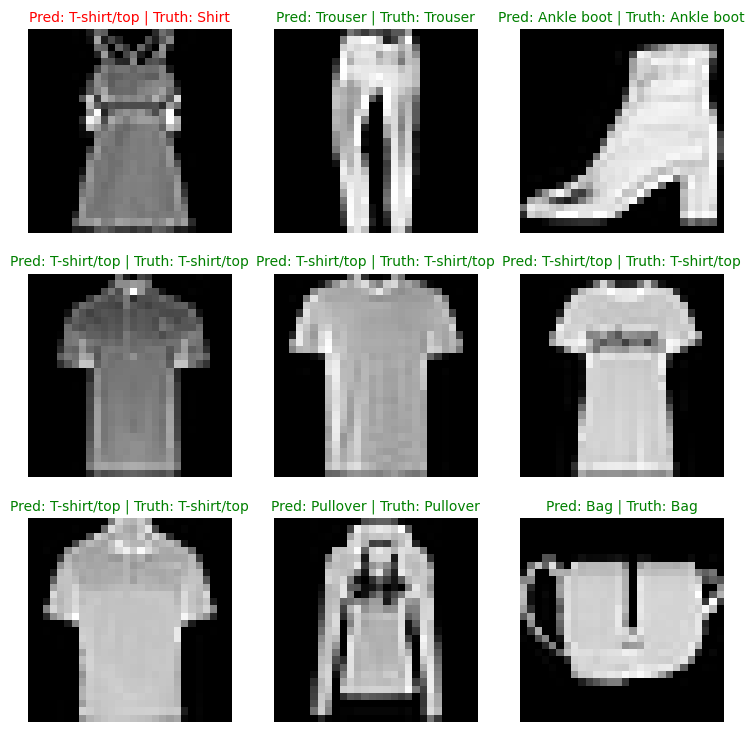

In [62]:
# Plot predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i , sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # PLot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form eg: "Sandal")
  pred_label = class_names[pred_classes[i]]

  #  Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change the title color accordingly
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
    plt.title(title_text,fontsize=10, c="r" )  # red if wrong

  plt.axis(False)

##Confusion matrix: For further prediction evaluation

A confusion matrics show where your classification model get confused between predictions and true labels

To make a confusion matrix, we'll go through three steps:
>1. Make predictions with our trained model, `model_2` (a confusion matrix compares predictions to true labels).
>2. Make a confusion matrix using `torchmetrics.ConfusionMatrix`.
>3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`.

In [63]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/1875 [00:00<?, ?it/s]

Now we got predictions thus we got through steps 2 & 3. Make confusion matrix using `torchmetrics.ConfusionMatrix`. 3 Plot the confiusion matrix using the `mlxtend.plotting.plot_confusion_matrix()`

In [ ]:
# See if torchmetrics exists, if not install it
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtenderison should be 0.19.0 or higher"
except:
  !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")


In [65]:
# To make plot we need mlxtend upgraded version ( 0.10.0 or higher)
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher



0.24.0


In [75]:
import torch
import matplotlib.pyplot as plt

num_classes = 10
conf_mat = torch.zeros(num_classes, num_classes, dtype=torch.int64)

model_0.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        preds = model_0(X).argmax(dim=1)
        for t, p in zip(y, preds):
            conf_mat[t, p] += 1


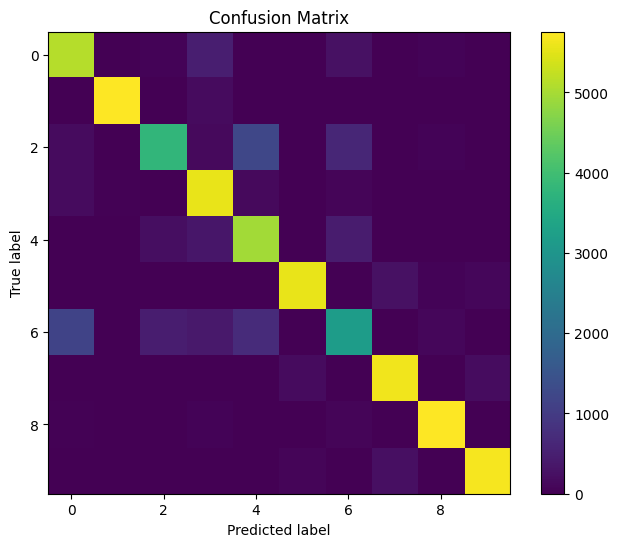

In [76]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_mat)
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()


### I avoid using the below code has dependency issue


In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2 Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3 Plotting the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),  # # matplotlib likes working with NumPy
    class_names=class_names,   # turn the row and column labels into class names
    figsize=(10, 7)
);

#Save and load best performing model


In [67]:
from pathlib import Path

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


In [68]:
# Create a new instance of FashionMNISTModelV2 (the same class as our saved state_dict())
# Note: loading model will error if the shapes here aren't the same as the saved version
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                    hidden_units=10, # try changing this to 128 and seeing what happens
                                    output_shape=10)

# Load in the saved state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send model to GPU
loaded_model_2 = loaded_model_2.to(device)

In [69]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.28585588932037354,
 'model_acc': 89.645}

In [70]:
model_2_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.28585588932037354,
 'model_acc': 89.645}

In [71]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(model_2_results["model_loss"]),
                torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance


tensor(True)